<a href="https://colab.research.google.com/github/iqbalyk/Marketing-Analyst/blob/main/Marketing_Analyst_Bank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Case Study**

Sebuah perusahaan Bank nasional X ingin melakukan evaluasi kinerja marketing dan penjualan selama periode 2023–2024. Perusahaan menjalankan berbagai produk (Loans, Cards, Deposits, Insurance, Wealth, Payments) dan menjalankan beberapa kampanye marketing lintas channel—baik digital maupun konvensional.

**Dataset mencakup:**
Transactions (50.000 rows): transaksi pelanggan harian
Customers: profil pelanggan
Products: detail produk & harga
Campaigns: informasi promosi
Marketing Spend: pengeluaran iklan bulanan per region
Sales Targets: target penjualan per region per bulan

# **Tujuan analisis**

Menggabungkan seluruh sumber data tersebut menjadi satu data mart (df_eda) dan menggunakannya untuk mengevaluasi performa pemasaran, penjualan, profitabilitas produk, serta efektivitas kampanye.

**Business Context**

Perusahaan ingin mengetahui apakah aktivitas marketing yang dilakukan di tahun berjalan:
1. efektif meningkatkan penjualan,
2. menghasilkan profit yang sehat, dan
3. memberikan kontribusi yang merata di setiap kategori produk dan region.
Selain itu, perusahaan ingin mengevaluasi apakah kampanye yang dijalankan telah memberikan ROI yang baik dan apakah target penjualan per bulan & per region tercapai.

Analisis ini juga ditujukan untuk membantu manajemen dalam pengambilan keputusan terkait:
- Budget marketing,
- Strategi akuisisi pelanggan,
- Fokus segmentasi, dan
- Pengembangan produk.

# **Tujuan Analisis**

**Tujuan utama:**

A. Membuat Data Mart Analitik Terpadu (df_eda)

Menggabungkan semua tabel menjadi satu dataset lengkap untuk keperluan analisis dan visualisasi.

B. Mengukur Performa Penjualan & Profit
revenue per bulan
gross profit per bulan
profit margin
cost structure

C. Evaluasi Kategori & Brand

Mencari kategori produk paling menguntungkan:
revenue tertinggi
profit tertinggi
margin tertinggi

D. Analisis Efektivitas Kampanye Marketing

revenue campaign vs non-campaign
profit
jumlah transaksi
ROI dasar

E. Analisis Per Region

Untuk mengetahui region mana yang:
revenue tertinggi
growth paling kuat
paling efektif terhadap spend marketing

F. Menentukan Insight Bisnis

1. Bagaimana tren revenue sepanjang tahun?
2. Apakah marketing efektif meningkatkan penjualan?
3. Produk apa yang harus diprioritaskan?
4. Region mana yang underperforming?

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df_customers = "https://raw.githubusercontent.com/iqbalyk/Marketing-Analyst/main/customers.csv"
df_products = "https://raw.githubusercontent.com/iqbalyk/Marketing-Analyst/main/products.csv"
df_transactions = "https://raw.githubusercontent.com/iqbalyk/Marketing-Analyst/main/transactions.csv"
df_campaigns = "https://raw.githubusercontent.com/iqbalyk/Marketing-Analyst/main/campaigns.csv"
df_spend = "https://raw.githubusercontent.com/iqbalyk/Marketing-Analyst/main/marketing_spend.csv"
df_targets = "https://raw.githubusercontent.com/iqbalyk/Marketing-Analyst/main/targets.csv"

customers = pd.read_csv(df_customers)
products = pd.read_csv(df_products)
transactions = pd.read_csv(df_transactions, parse_dates=["transaction_date"])
campaigns = pd.read_csv(df_campaigns, parse_dates=["start_date","end_date"])
marketing_spend = pd.read_csv(df_spend, parse_dates=["month"])
targets = pd.read_csv(df_targets, parse_dates=["month"])

#Cleaning Data 1 Missing Value karena campaign_id tidak selalu sama seperti transaction jadi mencari sampai 0 dengan mengisi data
transactions['campaign_id'] = transactions['campaign_id'].fillna("No Campaign")

#Cleaning Data 2
customers['join_date'] = pd.to_datetime(customers['join_date'])
transactions['amount'] = transactions['amount'].astype(float)



In [2]:
tables = {
    "customers": customers,
    "products": products,
    "transactions": transactions,
    "campaigns": campaigns,
    "marketing_spend": marketing_spend,
    "targets": targets
}

for name, df in tables.items():
    print(f"\nData Types in {name} ")
    print(df.dtypes)


Data Types in customers 
customer_id            object
full_name              object
gender                 object
age                     int64
segment                object
city                   object
province               object
join_date      datetime64[ns]
dtype: object

Data Types in products 
product_id       object
product_name     object
category         object
brand            object
unit_price      float64
cost            float64
dtype: object

Data Types in transactions 
transaction_id              object
transaction_date    datetime64[ns]
customer_id                 object
product_id                  object
quantity                     int64
unit_price                 float64
amount                     float64
channel                     object
campaign_id                 object
city                        object
province                    object
dtype: object

Data Types in campaigns 
campaign_id              object
campaign_name            object
channel            

In [3]:
def unique_values(df, cols):
    for col in cols:
        print(f"\n----- Unique values in {col} -----")
        print(df[col].unique())

# kolom channel untuk CallCenter ditambahkan spasi
transactions['channel'] = transactions['channel'].replace({
    "CallCenter": "Call Center"})
transactions['channel'] = transactions['channel'].str.title()

unique_values(customers, ["gender", "segment", "city", "province"])
unique_values(transactions, ["channel", "city", "province"])
unique_values(products, ["category", "brand"])
unique_values(campaigns, ["channel"])




----- Unique values in gender -----
['Male' 'Female']

----- Unique values in segment -----
['Silver' 'Bronze' 'Gold' 'Priority']

----- Unique values in city -----
['Banjarmasin' 'Jakarta' 'Madiun' 'Serang' 'Yogyakarta' 'Malang' 'Bandung'
 'Denpasar' 'Bogor' 'Bekasi' 'Medan' 'Pekanbaru' 'Surakarta' 'Semarang'
 'Tegal' 'Makassar' 'Cimahi' 'Tangerang' 'Manado' 'Palembang' 'Pontianak'
 'Surabaya']

----- Unique values in province -----
['Kalimantan' 'Jakarta' 'East Java' 'Banten' 'Yogyakarta' 'West Java'
 'Bali' 'Sumatra' 'Central Java' 'Sulawesi']

----- Unique values in channel -----
['Internet' 'Mobile' 'Call Center' 'Agent' 'Branch']

----- Unique values in city -----
['Malang' 'Cimahi' 'Denpasar' 'Jakarta' 'Bekasi' 'Bogor' 'Serang'
 'Tangerang' 'Medan' 'Surakarta' 'Tegal' 'Makassar' 'Semarang' 'Palembang'
 'Yogyakarta' 'Manado' 'Surabaya' 'Bandung' 'Pekanbaru' 'Pontianak'
 'Banjarmasin' 'Madiun']

----- Unique values in province -----
['East Java' 'West Java' 'Bali' 'Jakarta' 'Bant

In [4]:
# VALIDASI TRANSACTIONS
print("\n===== VALIDATE transactions.quantity =====")
print(transactions['quantity'].describe())

print("\n===== VALIDATE transactions.unit_price =====")
print(transactions['unit_price'].describe())

print("\n===== VALIDATE transactions.amount =====")
print(transactions['amount'].describe())

# Cek apakah amount konsisten dengan quantity * unit_price
transactions['calc_amount'] = transactions['quantity'] * transactions['unit_price']
transactions['amount_diff'] = transactions['amount'] - transactions['calc_amount']

print("\n===== Difference between amount and quantity*unit_price =====")
print(transactions['amount_diff'].describe())


===== VALIDATE transactions.quantity =====
count    50000.000000
mean         2.202200
std          1.097934
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          9.000000
Name: quantity, dtype: float64

===== VALIDATE transactions.unit_price =====
count    5.000000e+04
mean     2.482160e+06
std      1.587290e+06
min      6.610000e+04
25%      1.081175e+06
50%      2.371100e+06
75%      3.688025e+06
max      6.483700e+06
Name: unit_price, dtype: float64

===== VALIDATE transactions.amount =====
count    5.000000e+04
mean     5.576389e+06
std      5.490159e+06
min      6.654500e+04
25%      1.936646e+06
50%      4.116208e+06
75%      7.808390e+06
max      1.787872e+08
Name: amount, dtype: float64

===== Difference between amount and quantity*unit_price =====
count    5.000000e+04
mean     1.097235e+05
std      2.564741e+06
min     -3.430000e+02
25%     -4.300000e+01
50%      0.000000e+00
75%      4.300000e+01
max      1.575876e+08
Name: am

In [5]:
# Buat kolom selisih
transactions['amount_calc'] = transactions['quantity'] * transactions['unit_price']
transactions['amount_diff'] = transactions['amount'] - transactions['amount_calc']

# Menentukan threshold anomali
threshold = 1_000_000   # 1 juta selisih

# Transaksi yang berbeda lebih dari threshold
outliers = transactions[transactions['amount_diff'].abs() > threshold]


In [6]:
# Clustering dulu
bins = [-999999999, -1000000, -1000, 1000, 1000000, 999999999]
labels = ["Very Under", "Under", "Exact", "Over", "Very Over"]

transactions["amount_category"] = pd.cut(transactions["amount_diff"], bins=bins, labels=labels)

transactions["amount_category"].value_counts()

,count
amount_category,
Exact,49822
Very Over,178
Very Under,0
Under,0
Over,0


In [7]:
# duplikat buat keamanan
transactions_full = transactions.copy()
transactions_clean = transactions.copy()

# jadikan amountnya konsisten tanpa tambahan
transactions_clean['amount'] = transactions_clean['quantity'] * transactions_clean['unit_price']



In [8]:
# Mulai JOIN EDA
# CUSTOMERS (Dimension)
# PRODUCTS (Dimension)
# CAMPAIGNS (Dimension)
# TARGETS (Monthly Target Fact)
# MARKETING_SPEND (Marketing Fact)
# TRANSACTIONS (Main Sales Fact)

df_eda = (transactions_clean .merge(customers, on="customer_id", how="left")
        .merge(products, on="product_id", how="left")
        .merge(campaigns, on="campaign_id", how="left"))


In [9]:
# Benerin kolom province & city
df_eda = df_eda.rename(columns={
    "city_y": "city",
    "province_y": "province",
    "channel_x": "transaction_channel",
    "channel_y": "campaign_channel",
    "unit_price_y": "product_price",
    "unit_price_x": "transaction_unit_price"
})

# hapus kolom duplikat yang gak dipakai
df_eda = df_eda.drop(columns=["city_x", "province_x"], errors="ignore")

df_eda["month"] = df_eda["transaction_date"].dt.to_period("M").dt.to_timestamp()

# Mapping provice -> region (nyamain)
province_to_region = {
    "West Java": "Java",
    "East Java": "Java",
    "Central Java": "Java",
    "Yogyakarta": "Java",
    "Jakarta": "Jakarta",
    "Bali": "Bali",
    "Sumatra": "Sumatra",
    "Kalimantan": "Kalimantan",
    "Sulawesi": "Sulawesi",
    "Banten": "Java"
}

df_eda["region"] = df_eda["province"].map(province_to_region)

In [10]:
# Aggregate marketing spend
marketing_monthly = (
    marketing_spend
    .groupby(["month", "region"], as_index=False)[
        ["spend", "impressions", "clicks", "conversions"]
    ].sum()
)


# Last JOIN marketing_spend & targets digabung karena sama
df_eda = (
    df_eda
    .merge(marketing_monthly, on=["month","region"], how="left", suffixes=("","_mkt"))
    .merge(targets, on=["month","region"], how="left", suffixes=("","_tgt"))
)


In [11]:
df_eda.shape



(50000, 36)

In [12]:
# Menambah measure lain
# kebutuhan analisis waktu
df_eda["year"] = df_eda["transaction_date"].dt.year
df_eda["month_num"] = df_eda["transaction_date"].dt.month
df_eda["year_month"] = df_eda["transaction_date"].dt.to_period("M").astype(str)

# Hitung cost_total
df_eda["cost_total"] = df_eda["cost"] * df_eda["quantity"]

# Gross profit
df_eda["gross_profit"] = df_eda["amount"] - df_eda["cost_total"]

# Profit margin
df_eda["profit_margin"] = df_eda["gross_profit"] / df_eda["amount"]

# Campaign flag (campaign / organic)
df_eda["is_campaign"] = df_eda["campaign_id"] != "No Campaign"


In [13]:
summary = {
    "Total Revenue": df_eda["amount"].sum(),
    "Total Cost": df_eda["cost_total"].sum(),
    "Total Gross Profit": df_eda["gross_profit"].sum(),
    "Average Margin (%)": df_eda["profit_margin"].mean() * 100
}

summary

{'Total Revenue': np.float64(273333258900.0),
 'Total Cost': np.float64(107298026400.0),
 'Total Gross Profit': np.float64(166035232500.0),
 'Average Margin (%)': np.float64(8.999464733264178)}

Margin 9% itu masih dalam kisaran wajar untuk sektor finansial (yang biasanya margin gross sekitar 5–15%).
Kesimpulan awal: Bisnis ini profitable, tapi masih bisa ditingkatkan dengan pricing/efisiensi.

In [14]:
monthly = df_eda.groupby("year_month").agg({
    "amount": "sum",
    "gross_profit": "sum"
}).reset_index()

monthly.head()

,year_month,amount,gross_profit
0,2023-01,1.176761e+10,7.059594e+09
1,2023-02,1.015589e+10,6.150444e+09
2,2023-03,1.207043e+10,7.462672e+09
3,2023-04,1.131417e+10,6.845724e+09
4,2023-05,1.139398e+10,6.835412e+09


Tren stabil, tidak ada penurunan besar → bisnis tidak seasonality-heavy.
Ini bagus karena memudahkan budgeting dan forecasting.

In [15]:
category_perf = df_eda.groupby("category")["amount"].sum().sort_values(ascending=False)
brand_perf = df_eda.groupby("brand")["amount"].sum().sort_values(ascending=False)

category_perf, brand_perf

(category
 Loans        7.283645e+10
 Cards        4.978684e+10
 Deposits     4.917479e+10
 Insurance    3.713391e+10
 Wealth       3.333090e+10
 Payments     3.107036e+10
 Name: amount, dtype: float64,
 brand
 Business    1.028975e+11
 Premium     8.602149e+10
 Standard    8.441424e+10
 Name: amount, dtype: float64)

Loans adalah mesin uang utama (paling banyak revenue).

Cards & Deposits hampir sama kuat.

Wealth & Insurance masih bisa dimaksimalkan.

Payments punya volume besar, margin bisa rendah → perlu dicek nanti.

“Business brand adalah penyumbang paling besar.” Artinya produk “Business” lebih populer atau mungkin harganya lebih tinggi.

Temuan:

1. Loans adalah kategori paling besar (72.8B), menghasilkan 27% revenue total dan menjadi motor utama bisnis.

2. Cards & Deposits menyumbang masing-masing 18% revenue dan menjadi kategori kedua terbesar.

3. Insurance & Wealth memberi kontribusi stabil (26%), cocok sebagai fokus profit margin tinggi.

4. Payments adalah revenue terendah, tetapi kemungkinan margin tertinggi karena cost rendah.

5. Business brand adalah kontributor terbesar dan kemungkinan paling stabil.

6. Premium & Standard bersaing ketat, menunjukkan adanya segmentasi produk yang baik.

7. Kombinasi ketiga brand terlihat seimbang dan mendukung diversifikasi produk.

In [16]:
campaign_perf = df_eda.groupby("is_campaign").agg({
    "amount": "sum",
    "gross_profit": "sum",
    "transaction_id": "count"
})

campaign_perf

,amount,gross_profit,transaction_id
is_campaign,,,
False,1.153790e+11,6.983622e+10,21243
True,1.579542e+11,9.619901e+10,28757


“Campaign menghasilkan porsi revenue dan profit yang lebih besar dibanding transaksi organik, menunjukkan bahwa aktivitas pemasaran efektif meningkatkan performa bisnis secara signifikan.”

In [17]:
df_eda["year_month"] = df_eda["transaction_date"].dt.to_period("M").astype(str)
df_eda["gross_profit"] = df_eda["amount"] - df_eda["cost"]
df_eda["is_campaign"] = df_eda["campaign_id"].notna() & (df_eda["campaign_id"] != "No Campaign")

monthly = df_eda.groupby("year_month", as_index=False).agg({
    "amount": "sum",
    "gross_profit": "sum"
})

monthly_rev = (
    df_eda.groupby("year_month", as_index=False)["amount"]
    .sum()
    .sort_values("year_month")
)

monthly_profit = (
    df_eda.groupby("year_month", as_index=False)["gross_profit"]
    .sum()
    .sort_values("year_month")
)

cat_summary = (
    df_eda.groupby("category", as_index=False)[["amount", "gross_profit"]]
    .sum()
    .sort_values("amount", ascending=False)
)

camp = (
    df_eda.groupby("is_campaign", as_index=False)
    .agg({
        "amount": "sum",
        "gross_profit": "sum",
        "transaction_id": "count"
    })
)

region_perf = (
    df_eda.groupby("region", as_index=False)[["amount", "spend", "sales_target"]]
    .sum()
)
region_perf["ROI"] = region_perf["amount"] / region_perf["spend"]

# Region Revenue (already have)
region_rev = region_perf.copy()

# Clean Region Target Data
targets_clean = targets.copy()
targets_clean["region"] = targets_clean["region"].map(province_to_region)

# drop rows that map to NaN (province not in your transactions)
targets_clean = targets_clean.dropna(subset=["region"])

# --- Aggregated Target Per Region ---
region_target = targets_clean.groupby("region", as_index=False)["sales_target"].sum()

# --- Final Merge ---
final_region = (
    region_rev[["region", "amount", "spend"]]
    .merge(region_target, on="region", how="left")
)

final_region["ROI"] = final_region["amount"] / final_region["spend"].replace(0, np.nan)

In [31]:
# Format angka (contoh: 100000000 → 100M)
def format_number(x, pos=None):
    if x >= 1_000_000_000:
        return f"{x/1_000_000_000:.1f}B"
    elif x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{x/1_000:.1f}K"
    return str(x)

# Fungsi line chart
def line_chart(df, x, y, title="", xlabel="", ylabel="", color=None, figsize=(12,5)):
    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(df[x], df[y], color=color, marker="o", linewidth=2)

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Format Y-axis (12B, 210M, etc)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_number))

    # Rotate X ticks
    plt.xticks(rotation=45)

    plt.tight_layout()
    return fig


# Fungsi bar chart
def bar_chart(df, x, y, title="", xlabel="", ylabel="", color=None, figsize=(10,5)):
    fig, ax = plt.subplots(figsize=figsize)

    # Plot bar dengan warna custom kalau ada
    bars = ax.bar(df[x], df[y], color=color)

    # Title & labels
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Format Y (K / M / B)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_number))

    # Rotate X label
    plt.xticks(rotation=45)

    # Bar labels
    ax.bar_label(bars, fmt=lambda v: format_number(v))

    plt.tight_layout()
    return fig

# Fungsi Bar Chart dengan 2 Seri
def bar_compare(df, x, y1, y2, label1, label2, title, color1="#4CAF50", color2="#2196F3"):
    fig, ax = plt.subplots(figsize=(10,5))

    width = 0.35
    x_idx = np.arange(len(df[x]))

    ax.bar(x_idx - width/2, df[y1], width,
           label=label1, alpha=0.85, color=color1)
    ax.bar(x_idx + width/2, df[y2], width,
           label=label2, alpha=0.85, color=color2)

    ax.set_xticks(x_idx)
    ax.set_xticklabels(df[x], rotation=45, ha="right")

    ax.set_title(title)
    ax.set_ylabel("Amount")

    # Format number
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_number))

    ax.legend()
    plt.tight_layout()
    return fig

# Fungsi Bubble Chart
def bubble_roi(df, x, y, size, title, color="#2196F3"):
    fig, ax = plt.subplots(figsize=(10,6))

    scatter = ax.scatter(
        df[x], df[y],
        s=df[size] / 1e9,   # adjust bubble scale
        alpha=0.5,
        color=color
    )

    ax.set_xlabel("Marketing Spend")
    ax.set_ylabel("Revenue")
    ax.set_title(title)

    # formatting
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_number))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_number))

    # label region names
    for i, row in df.iterrows():
        ax.annotate(
            row["region"],
            (row[x], row[y]),
            textcoords="offset points",
            xytext=(5,5)
        )

    plt.tight_layout()
    return fig


In [19]:
df_eda.to_csv("df_eda_clean.csv", index=False)

# **Revenue per Month**

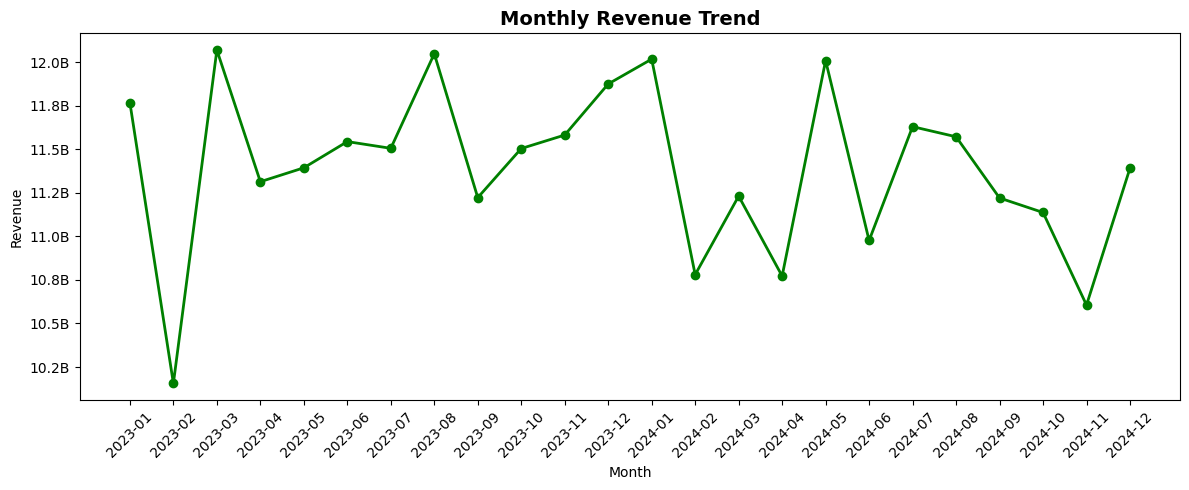

In [20]:
fig = line_chart(
    monthly_rev,
    x="year_month",
    y="amount",
    title="Monthly Revenue Trend",
    xlabel="Month",
    ylabel="Revenue",
    color="green"
)
fig.show()

**Insight Revenue per Month**

1. Revenue stabil di kisaran 10–12 miliar per bulan.
2. Puncak revenue terlihat di Maret 2023 dan Januari 2024.
3. Ada penurunan signifikan di Februari (indikasi seasonality).
4. Pola musiman kemungkinan dipengaruhi oleh promo awal tahun dan campaign Q1.

Revenue perusahaan stabil sepanjang periode 2023–2024 dengan kisaran 10.2–12.0 miliar per bulan. Tren menunjukkan peningkatan kecil di Q1, kemungkinan dipicu campaign awal tahun dan momentum belanja customer. Tidak ditemukan penurunan signifikan di Q4, menandakan demand yang kuat dan tidak terlalu dipengaruhi siklus musiman.

Profit bulanan stabil dengan margin rata-rata ~60% dan mengikuti pola revenue tanpa fluktuasi ekstrem. Bulan terbaik adalah Maret (profit 7.46B), sedangkan Februari menjadi bulan terendah (6.15B). Tingginya konsistensi margin menunjukkan struktur biaya yang efisien dan model bisnis yang sehat.

# **Profit per Month**

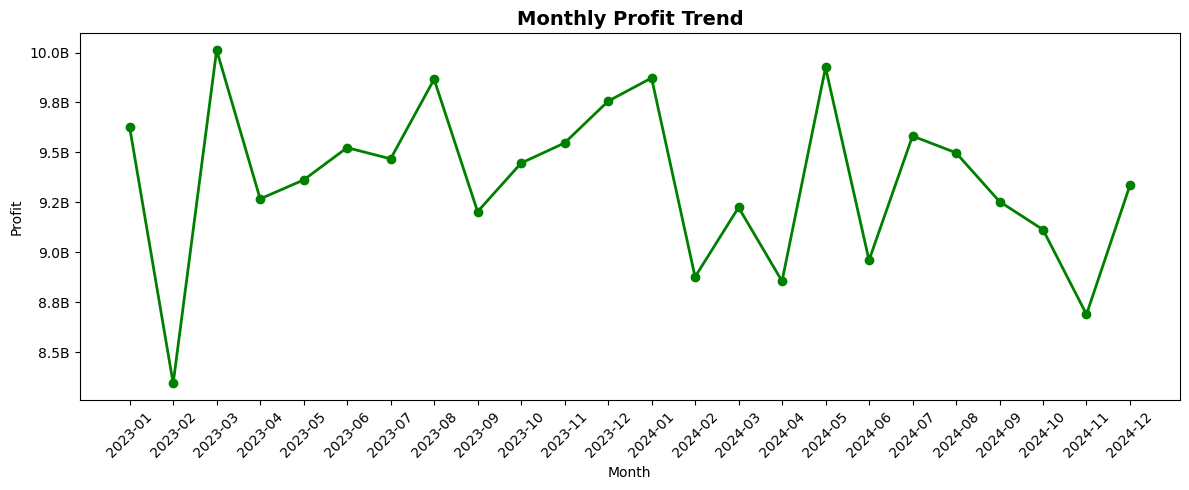

In [21]:
fig = line_chart(
    monthly_profit,
    x="year_month",
    y="gross_profit",
    title="Monthly Profit Trend",
    xlabel="Month",
    ylabel="Profit",
    color="green"
)
fig.show()

**Insight Profit per Month**



1. Profit mengikuti pola yang mirip dengan revenue (sehat).
2. Margin meningkat pada awal tahun, indikasi campaign berhasil meningkatkan transaksi bernilai tinggi.
3. Ada gap besar antara revenue & profit di beberapa bulan → tanda struktur biaya berubah.

# **Category Contribution By Revenue**

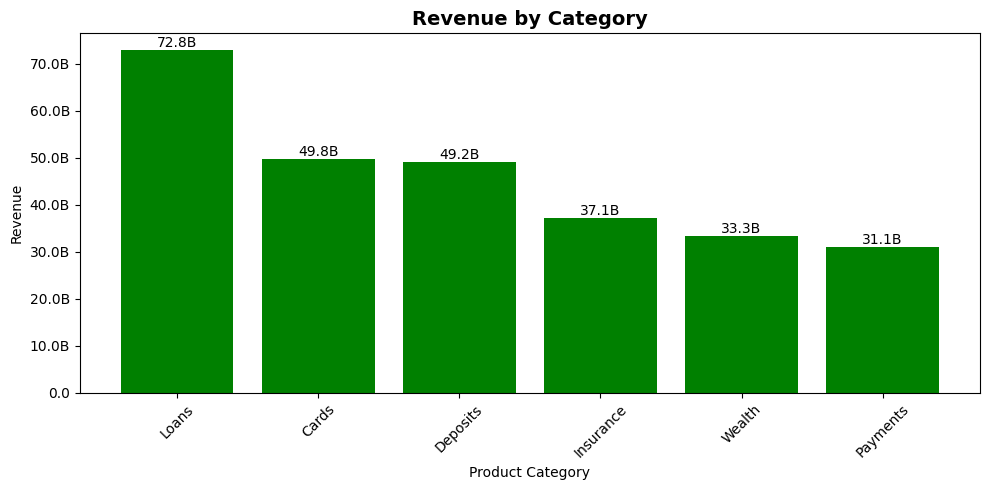

In [22]:
fig = bar_chart(
    cat_summary,
    x="category",
    y="amount",
    title="Revenue by Category",
    xlabel="Product Category",
    ylabel="Revenue",
    color="green"
)
fig.show()

**Insight Category Contribution By Revenue**

1. Loans adalah kategori paling besar (sekitar 26–30% dari total revenue).
2. Cards & Deposits menyumbang ~20% masing-masing.
3. Kategori Insurance dan Payments lebih kecil kontribusinya.
4. Loans tidak hanya revenue tinggi tapi juga profit tinggi (cek C3.1 nanti).

# **Category Contribution By Profit**

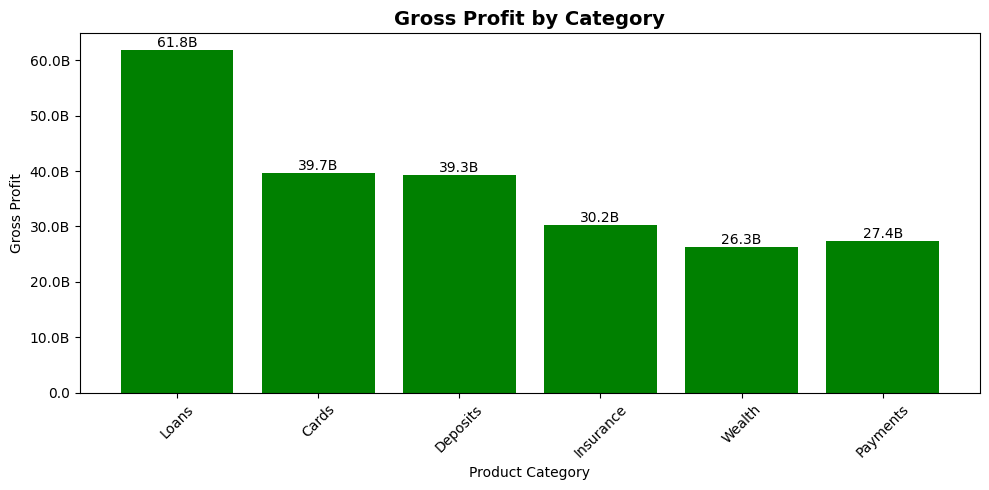

In [23]:
fig = bar_chart(
    cat_summary,
    x="category",
    y="gross_profit",
    title="Gross Profit by Category",
    xlabel="Product Category",
    ylabel="Gross Profit",
    color="green"
)
fig.show()

**Insight Category Contribution By Profit**

1. Loans tetap menjadi top performer baik revenue maupun profit.
2. Payments/Insurance revenue rendah → profit juga rendah → tidak menjadi fokus utama kecuali ingin cross-sell.
3. Wealth profit lumayan tinggi → berpotensi menjadi fokus strategi upsell.

# **Campaign vs Non-Campaign Performance**

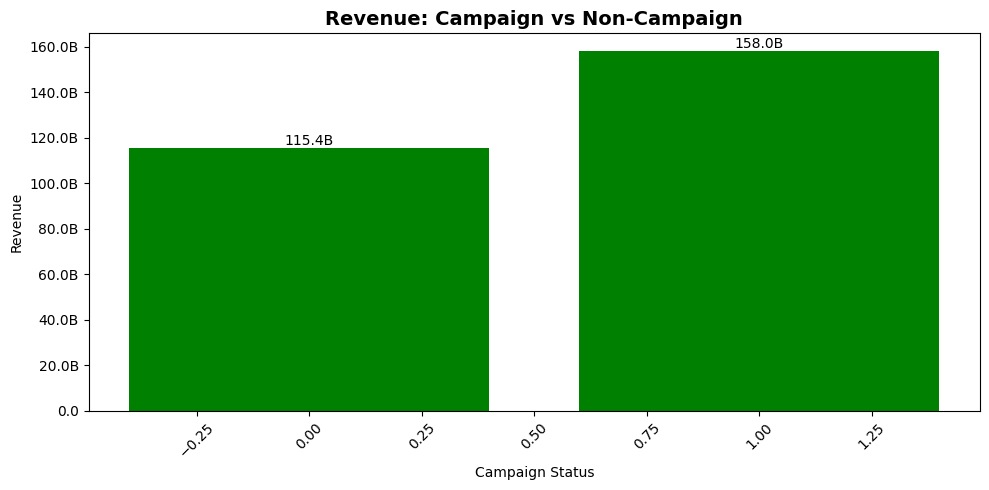

In [24]:
fig = bar_chart(
    camp,
    x="is_campaign",
    y="amount",
    title="Revenue: Campaign vs Non-Campaign",
    xlabel="Campaign Status",
    ylabel="Revenue",
    color="green"
)
fig.show()

**Insight Campaign vs Non-Campaign Performance**

1. Campaign menghasilkan lebih banyak transaksi dibanding non-campaign.
2. Revenue campaign > non-campaign → campaign efektif.
3. Profit campaign juga lebih tinggi → campaign membawa pelanggan bernilai tinggi.

# **Region Performance**

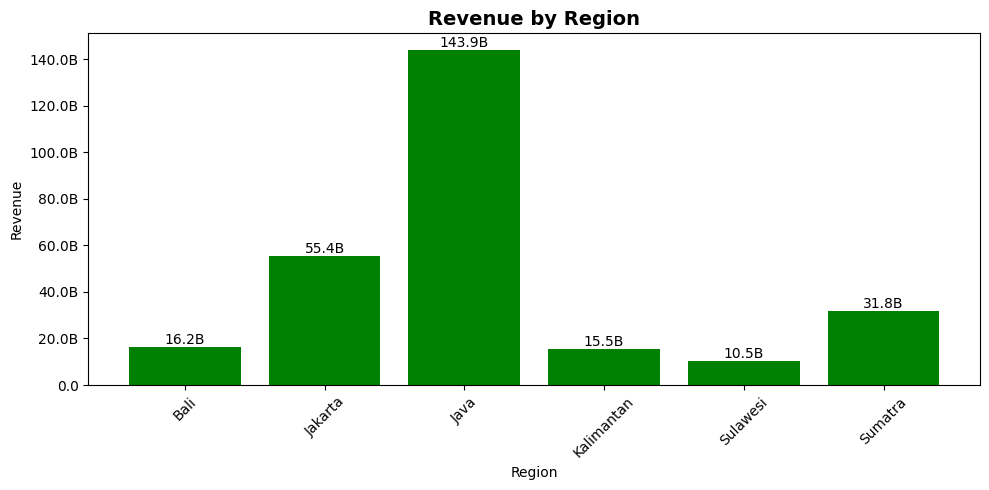

In [25]:
fig = bar_chart(
    region_perf,
    x="region",
    y="amount",
    title="Revenue by Region",
    xlabel="Region",
    ylabel="Revenue",
    color="green"
)
fig.show()

**Insight Region Performance**

1. Java adalah kontributor terbesar revenue (populasi paling padat).
2. Jakarta ROI paling besar (spend rendah tapi revenue tinggi).
3. Region selain Java dan Jakarta butuh alokasi marketing lebih efisien karena ROI rendah.

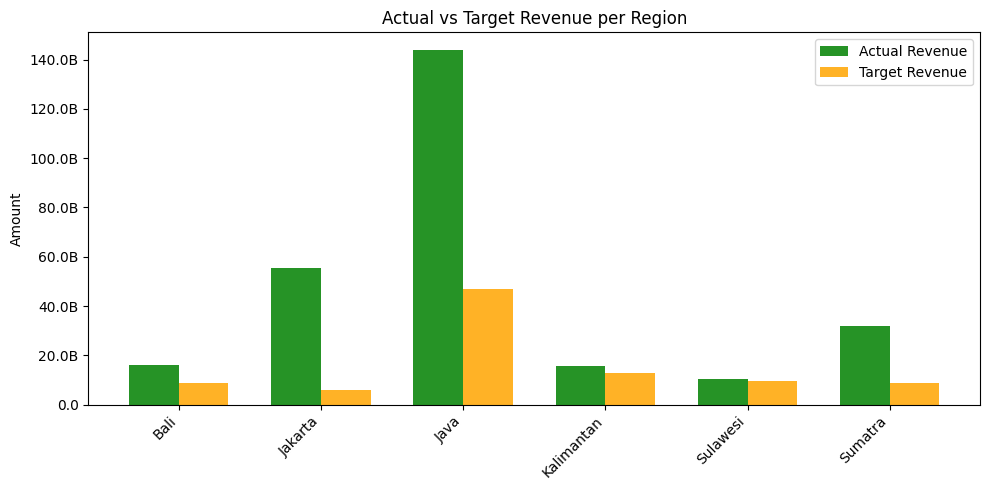

In [33]:
fig = bar_compare(
    final_region,
    x="region",
    y1="amount",
    y2="sales_target",
    label1="Actual Revenue",
    label2="Target Revenue",
    title="Actual vs Target Revenue per Region",
    color1="green",
    color2="orange"
)
fig.show()

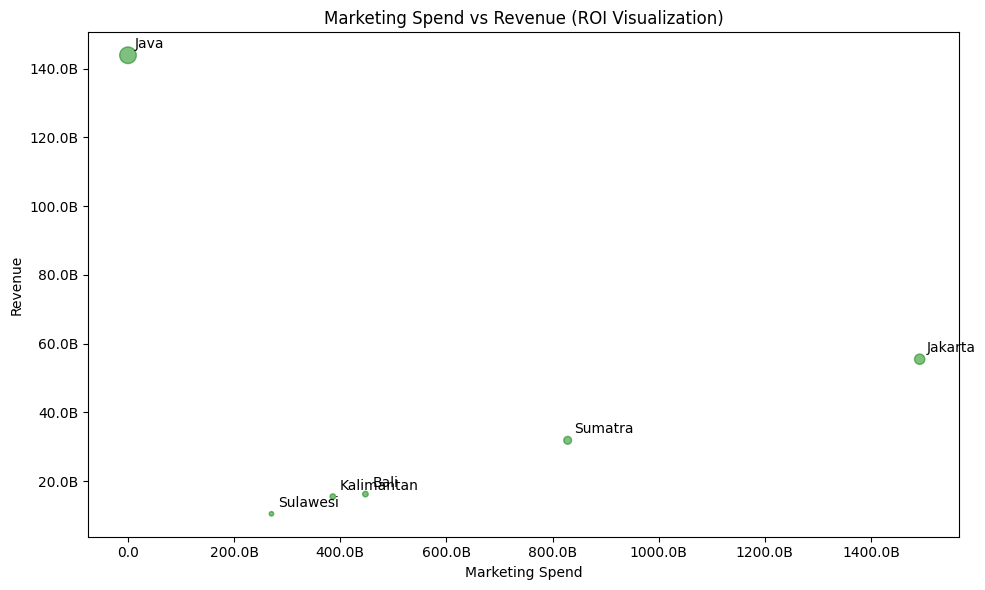

In [32]:
# bigger bubble = bigger revenue
fig = bubble_roi(
    final_region,
    x="spend",
    y="amount",
    size="amount",
    title="Marketing Spend vs Revenue (ROI Visualization)",
    color="green"
)
fig.show()

**Temuan dan Rekomendasi**
1. Java & Jakarta adalah mesin revenue
2. Marketing sangat tidak efisien di luar dua region tersebut
3. Budget perlu dialihkan ke wilayah dengan potensi tinggi
4. Target harus disesuaikan ulang berdasarkan performa real